In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 97.6 MB/s eta 0:00:00


In [ ]:
!pip install scikit-learn

In [ ]:
# !pip uninstall opencv-python-headless -y

!pip install opencv-python --upgrade

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
from torchsummary import summary
from typing import Dict, List, Tuple
import matplotlib.image as mpimg
from tempfile import TemporaryDirectory
import cv2
import numpy as np
import matplotlib.pyplot as plt




In [ ]:
data_dir = '/content/drive/MyDrive/Transfer learning/new_image_quality'

In [ ]:
from torchvision import datasets

dataset = datasets.ImageFolder(data_dir)

# Get class names
class_names = dataset.classes

# Initialize a dictionary to count items in each class
class_counts = {class_name: 0 for class_name in class_names}

# Count the number of items in each class
for _, label in dataset.samples:
    class_name = class_names[label]
    class_counts[class_name] += 1

# Print the number of items in each class
for class_name, count in class_counts.items():
    print(f'Class: {class_name}, Count: {count}')

Class: blurry, Count: 489
Class: dark, Count: 500
Class: good, Count: 487
Class: mucus, Count: 428


Training set size: 1523
Validation set size: 381
['blurry', 'dark', 'good', 'mucus']


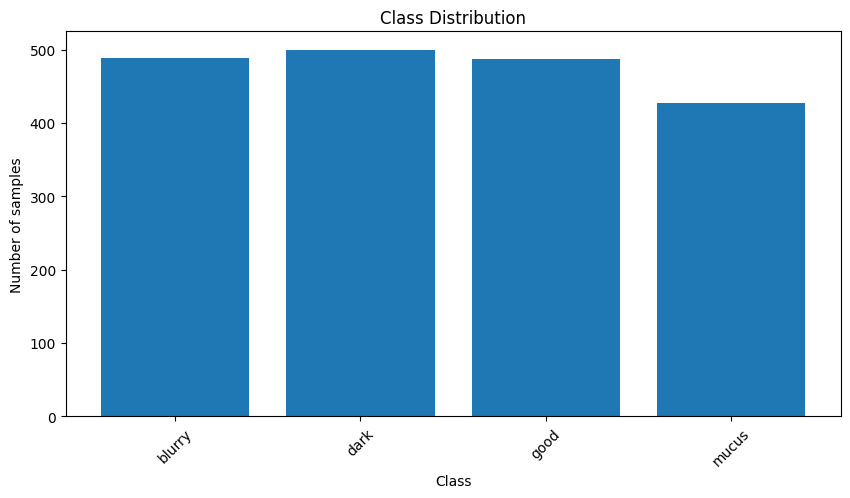

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to fixed size
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to fixed size
        transforms.CenterCrop(156),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load the entire dataset
full_dataset = datasets.ImageFolder(os.path.join(data_dir), data_transforms['train'])

# Define the split ratio
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Split the dataset
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=16, shuffle=True, num_workers=2)
}




# Get dataset sizes
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}



class_names = full_dataset.classes

print(f"Training set size: {dataset_sizes['train']}")
print(f"Validation set size: {dataset_sizes['val']}")
print(class_names)


# Count the number of samples for each class
class_counts = np.bincount(full_dataset.targets)
class_indices = np.arange(len(class_counts))

# Plot the class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_indices, class_counts, tick_label=class_names)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()


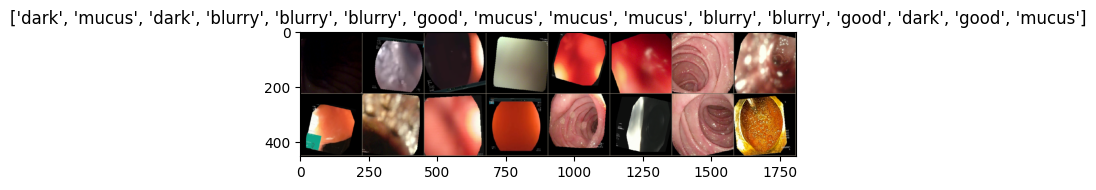

In [ ]:
#visualze a few image
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders['train']))

out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=100):
    since = time.time()

    #checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        # Initialize lists to store loss and accuracy
        train_loss_history = []
        val_loss_history = []
        train_acc_history = []
        val_acc_history = []

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} Epoch {epoch}/{num_epochs - 1}'):
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()


                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, torch.nn.functional.one_hot(labels, num_classes=4).float())


                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Store loss and accuracy
                if phase == 'train':
                    train_loss_history.append(epoch_loss)
                    train_acc_history.append(epoch_acc.cpu().numpy())
                else:
                    val_loss_history.append(epoch_loss)
                    val_acc_history.append(epoch_acc.cpu().numpy())

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [ ]:

def visualize_model(model, num_images=20):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]} ({probs[j].item()*100:.2f}%)')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [ ]:
def plot_training_history(train_loss, val_loss, train_acc, val_acc):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

In [ ]:
torch.cuda.empty_cache()

In [ ]:
model = models.resnet50(weights=False)
model.load_state_dict(torch.load('/content/drive/MyDrive/Transfer learning/RN50_GastroNet-200K_DINOv1.pth', map_location=torch.device('cpu'), weights_only=True), strict = False)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 4),
    nn.Softmax(dim=1)
)

model = model.to(device)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 0/99
----------


train Epoch 0/99: 100%|██████████| 96/96 [07:18<00:00,  4.57s/it]


train Loss: 0.1825 Acc: 0.3756


val Epoch 0/99: 100%|██████████| 24/24 [01:50<00:00,  4.61s/it]


val Loss: 0.1505 Acc: 0.5407

Epoch 1/99
----------


...

val Loss: 0.0635 Acc: 0.8504

Epoch 99/99
----------


train Epoch 99/99: 100%|██████████| 96/96 [00:11<00:00,  8.28it/s]


train Loss: 0.0651 Acc: 0.8496


val Epoch 99/99: 100%|██████████| 24/24 [00:02<00:00,  8.37it/s]


val Loss: 0.0602 Acc: 0.8504

Training complete in 33m 26s
Best val Acc: 0.887139


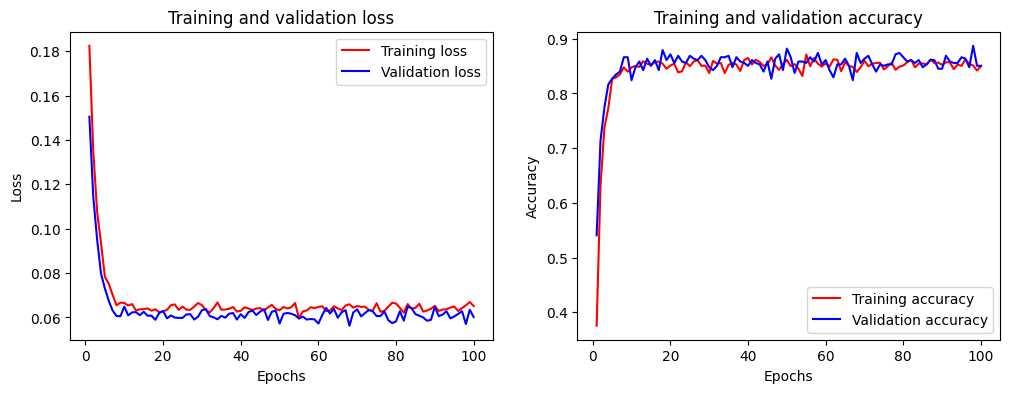

In [ ]:
model_ft, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, criterion, optimizer, scheduler, num_epochs=100)
plot_training_history(train_loss_history, val_loss_history, train_acc_history, val_acc_history)

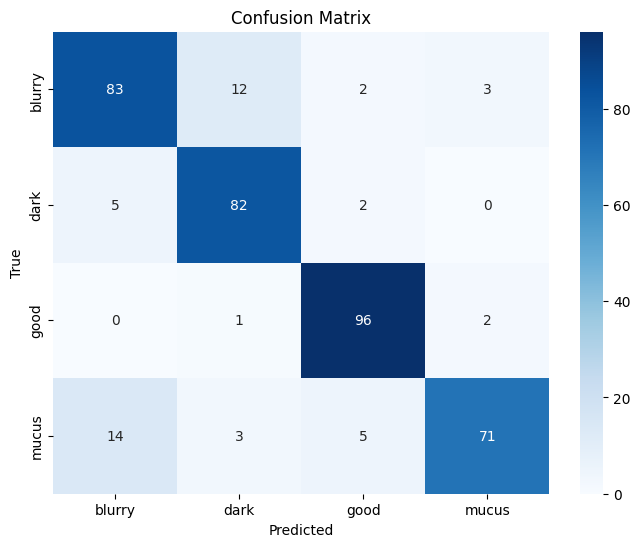

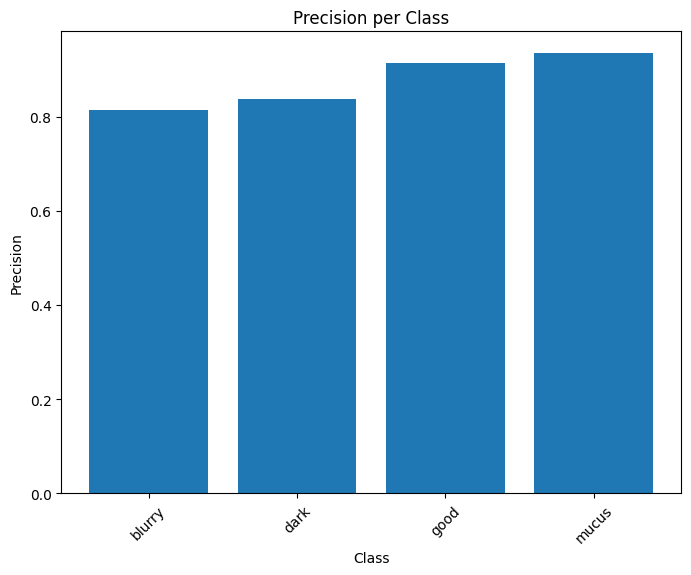

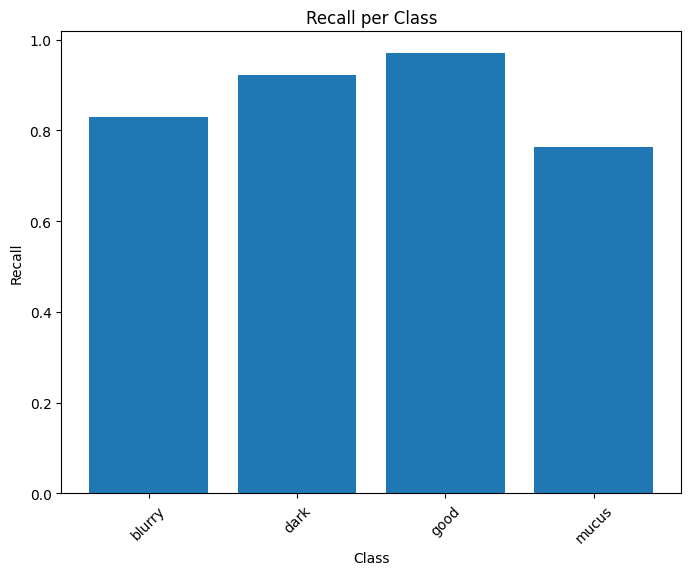

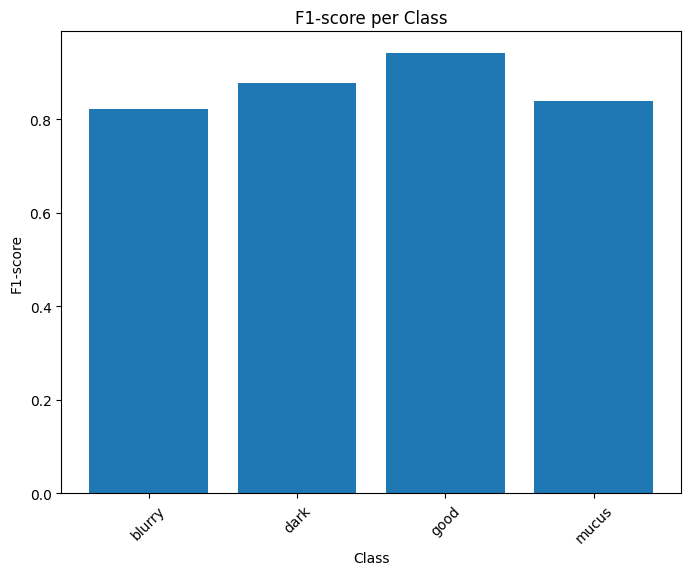

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming you have your model, dataloaders, and device defined

# Get predictions and ground truth labels for the validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate classification report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Plot other metrics
metrics = ['precision', 'recall', 'f1-score']
for metric in metrics:
    plt.figure(figsize=(8, 6))
    values = [report[label][metric] for label in class_names]
    plt.bar(class_names, values)
    plt.xlabel('Class')
    plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} per Class')
    plt.xticks(rotation=45)
    plt.show()

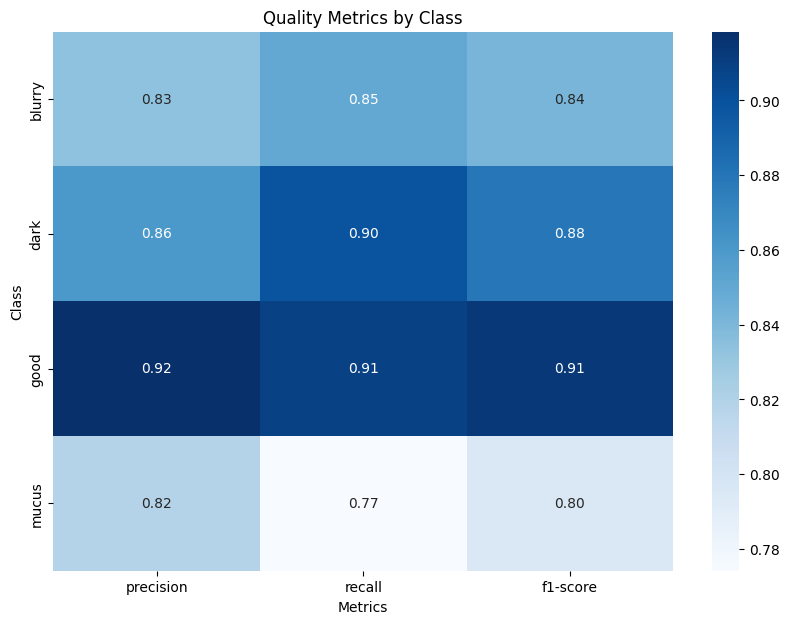

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_quality_metrics_by_class(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

    # Extract metrics
    metrics = ['precision', 'recall', 'f1-score']
    class_metrics = {metric: [] for metric in metrics}
    for class_name in class_names:
        for metric in metrics:
            class_metrics[metric].append(report[class_name][metric])

    # Create a DataFrame for the metrics
    metrics_df = pd.DataFrame(class_metrics, index=class_names)

    # Plot the metrics as a heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(metrics_df, annot=True, cmap='Blues', fmt='.2f')
    plt.title('Quality Metrics by Class')
    plt.xlabel('Metrics')
    plt.ylabel('Class')
    plt.show()

# After training the model, plot the quality metrics by class
plot_quality_metrics_by_class(model, dataloaders['val'])

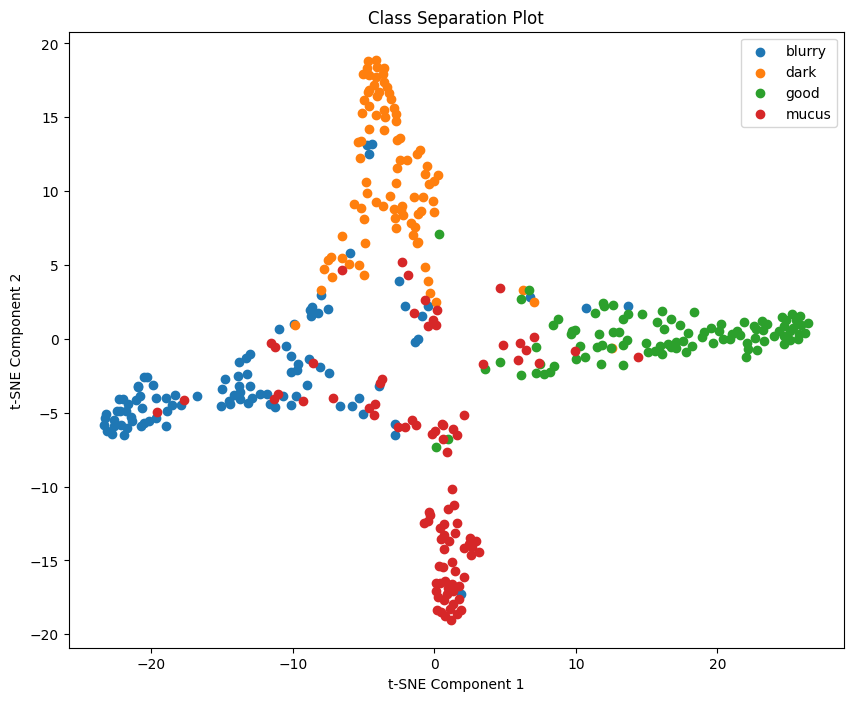

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_class_separation(model, dataloader):
    model.eval()
    features = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Extract features from the penultimate layer
            outputs = model(inputs)
            features.append(outputs.cpu().numpy())
            labels_list.append(labels.cpu().numpy())

    features = np.concatenate(features)
    labels_list = np.concatenate(labels_list)

    # Apply t-SNE to reduce dimensionality to 2D
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)

    # Plot the 2D features
    plt.figure(figsize=(10, 8))
    for class_index, class_name in enumerate(class_names):
        indices = np.where(labels_list == class_index)
        plt.scatter(features_2d[indices, 0], features_2d[indices, 1], label=class_name)

    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('Class Separation Plot')
    plt.legend()
    plt.show()

# After training the model, plot the class separation
plot_class_separation(model, dataloaders['val'])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix_and_quality_metrics(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:")
    print(cm)

    # Generate classification report
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("\nClassification Report:")
    print(report)

# After training the model, print the confusion matrix and quality metrics
print_confusion_matrix_and_quality_metrics(model, dataloaders['val'])

Confusion Matrix:
[[84  9  1  6]
 [ 3 83  2  1]
 [ 0  1 95  3]
 [15  3  4 71]]

Classification Report:
              precision    recall  f1-score   support

      blurry       0.82      0.84      0.83       100
        dark       0.86      0.93      0.90        89
        good       0.93      0.96      0.95        99
       mucus       0.88      0.76      0.82        93

    accuracy                           0.87       381
   macro avg       0.87      0.87      0.87       381
weighted avg       0.87      0.87      0.87       381



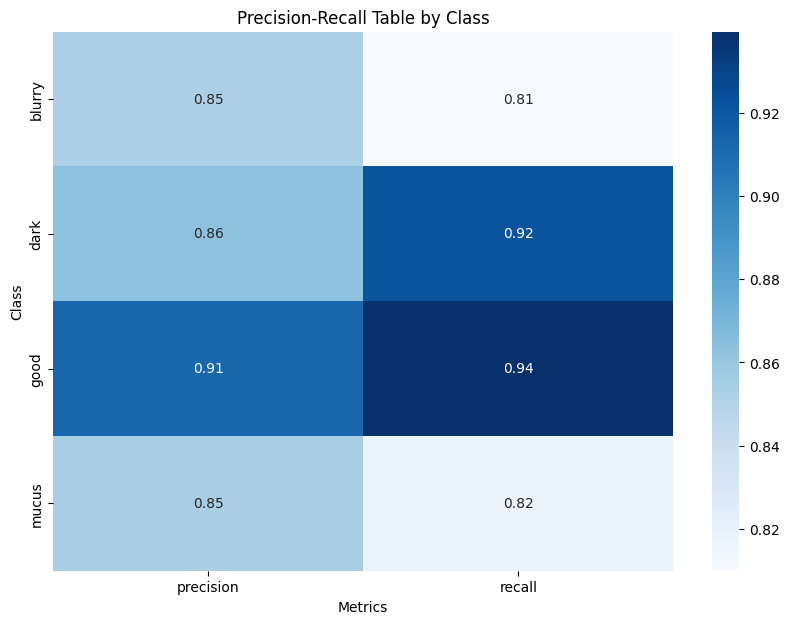

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_table(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

    # Extract precision and recall
    metrics = ['precision', 'recall']
    class_metrics = {metric: [] for metric in metrics}
    for class_name in class_names:
        for metric in metrics:
            class_metrics[metric].append(report[class_name][metric])

    # Create a DataFrame for the metrics
    metrics_df = pd.DataFrame(class_metrics, index=class_names)

    # Plot the metrics as a heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(metrics_df, annot=True, cmap='Blues', fmt='.2f')
    plt.title('Precision-Recall Table by Class')
    plt.xlabel('Metrics')
    plt.ylabel('Class')
    plt.show()

# After training the model, plot the precision-recall table
plot_precision_recall_table(model, dataloaders['val'])

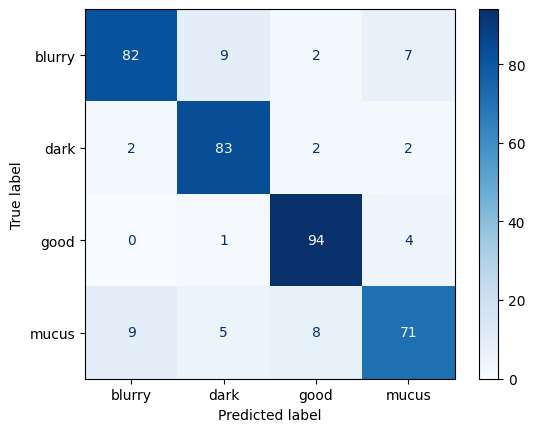

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

plot_confusion_matrix(model, dataloaders['val'])

In [ ]:
import torch.onnx

# Save the trained model for TensorRT
def save_model_for_tensorrt(model, path):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224, device=device)
    torch.onnx.export(model, dummy_input, path, export_params=True, opset_version=11, do_constant_folding=True, input_names=['input'], output_names=['output'])


save_model_for_tensorrt(model_ft, '/content/drive/MyDrive/Transfer learning/Image_quality_model_500.onnx')

In [ ]:
#save the model
torch.save(model.state_dict(), '/content/drive/MyDrive/Transfer learning/quality_model_500_2.pth')
#convert model to tensorrt


In [ ]:
# #load the test_model_3
# model = models.resnet50(weights=False)
# model.fc = nn.Linear(model.fc.in_features, 5)
# model.load_state_dict(torch.load('/content/drive/MyDrive/Transfer learning/test_model_3_no_overfit.pth', map_location=torch.device('cpu')), strict=False)
# model = model.to(device)
# model.eval()

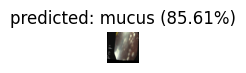

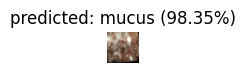

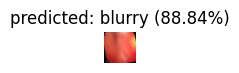

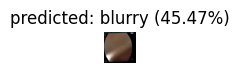

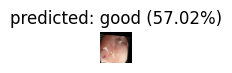

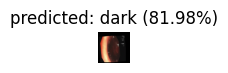

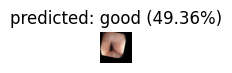

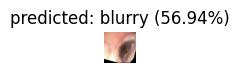

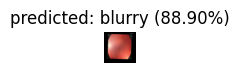

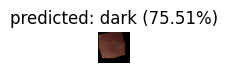

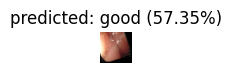

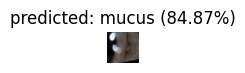

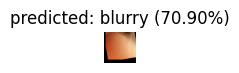

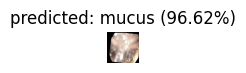

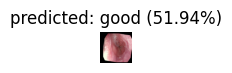

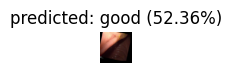

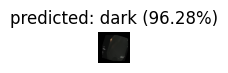

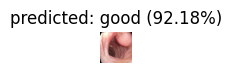

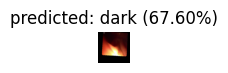

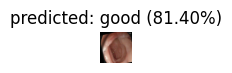

In [ ]:
visualize_model(model)

In [ ]:
def visualize_model_predictions(model, img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path).convert('RGB')
    img = data_transforms['val'](img)  # Apply validation transformation
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2, 2, 1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

    model.train(mode=was_training)

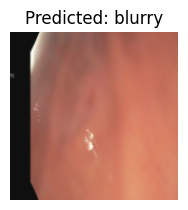

In [ ]:
 visualize_model_predictions(
    model,
    img_path='/content/drive/MyDrive/Transfer learning/classified_frames/ulcer_9/blurry/frame_52.jpg'
)

CLASSIFY ON A VIDEO

testing model
